# **Task 1: Exploratory Data Analysis (EDA)**

In [2]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
#loading the dataset
telecome_df = pd.read_csv("/content/Telco-Customer-Churn.csv")

In [4]:
# getting first five rows of dataset
telecome_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset Attributes

In [5]:

telecome_df.shape  #no. of rows and column

(7043, 21)

In [6]:
telecome_df.columns.values #return column headings

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [7]:
telecome_df.dtypes #checking columns datatypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [8]:
telecome_df.isnull().sum() #checking null values

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
telecome_df.describe() #statistical overview of dataset

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
telecome_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
telecome_df['Churn'].value_counts() #categorical values of churn column

,count
Churn,
No,5174
Yes,1869


Data cleaning

In [12]:
tele_data = telecome_df.copy()

Total Charges should be numeric amount



In [13]:
tele_data.TotalCharges = pd.to_numeric(tele_data.TotalCharges, errors='coerce')
tele_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
tele_data.loc[tele_data['TotalCharges'].isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


## **1. Handling missing values**

1.1 Using "dropna()" since the % of these records compared to total dataset is very low ie 0.15%, it is safe to ignore them from further processing.



In [15]:
tele_data.dropna(inplace=True) #removing missing values


In [16]:
tele_data.duplicated().sum() #checking for duplicates(no duplicates)

np.int64(0)

1.2 Dividing the customers into differnt groups of 12 months based on tenure because max value of tenure is 72

In [17]:
# Geting the max tenure
print(tele_data['tenure'].max())

72


In [18]:
#Grouping the tenure in groups of 12
labels = ["{0} - {1}".format(i, i + 11) for i in range(1, 72, 12)]
tele_data['tenure_group'] = pd.cut(tele_data.tenure, range(1, 80, 12), right=False, labels=labels)

In [19]:
tele_data['tenure_group'].value_counts()

,count
tenure_group,
1 - 12,2175
61 - 72,1407
13 - 24,1024
25 - 36,832
49 - 60,832
37 - 48,762


In [20]:
tele_data.drop(columns=['customerID'], axis=1, inplace=True) # removing columns not required for processing
tele_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


## **2. Analysing class imbalance (in churn column).**

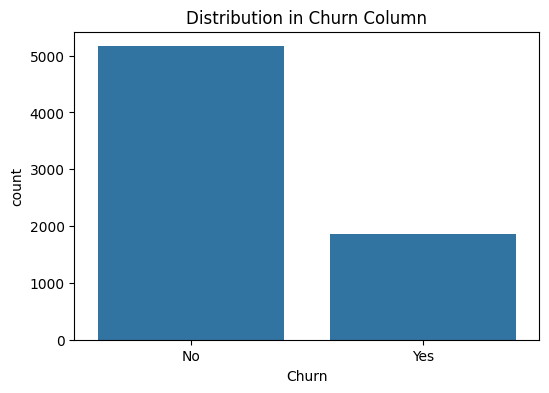

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=tele_data)#churn is categorical data
plt.title('Distribution in Churn Column')
plt.show()

In [22]:
tele_data['Churn'].value_counts(normalize=True)*100 #class imbalance in percentage

,proportion
Churn,
No,73.421502
Yes,26.578498


Dataset is highly imbalanced

*   Churned customers ≈ 27%
*   Retained customers ≈ 73%



Numerical Feature Analysis

In [23]:
numerical_cols = ["MonthlyCharges","TotalCharges"]

<function matplotlib.pyplot.show(close=None, block=None)>

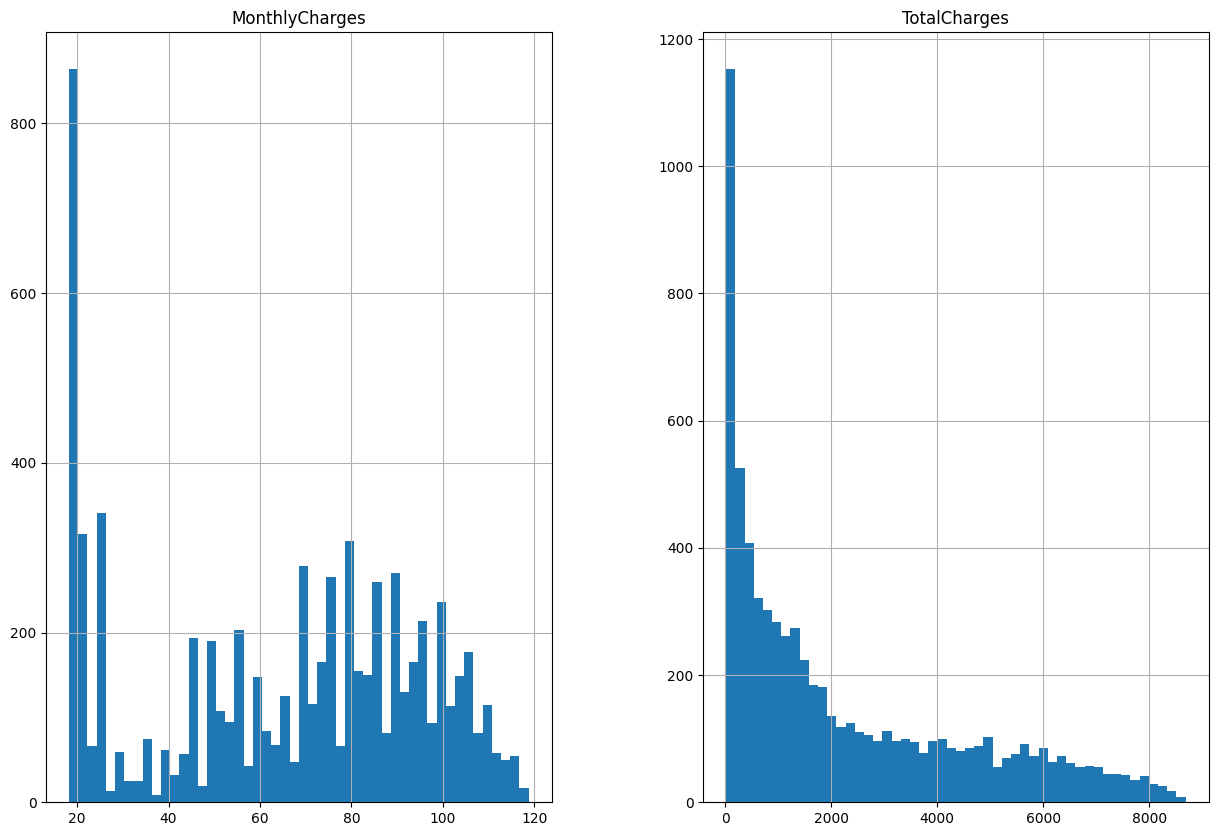

In [24]:
tele_data[numerical_cols].hist(figsize=(15,10),bins =50)
plt.show

## **3. Detecting and treating outliers**

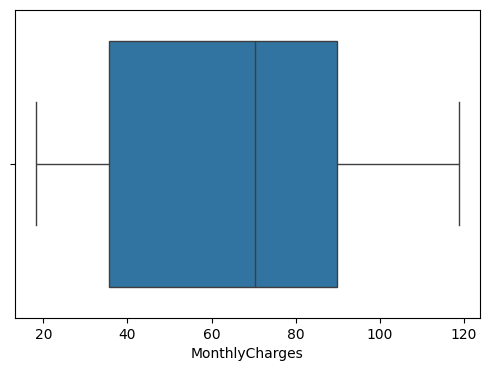

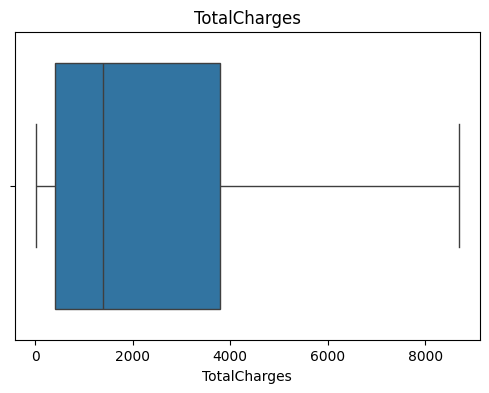

In [25]:
#boxplot for detecting Outliers
for col in numerical_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=tele_data[col])
plt.title(col)
plt.show()


using IQR for detecting outliers

For this dataset, the Interquartile Range (IQR) method is preferred over the Z-score method because numerical columns like MonthlyCharges and TotalCharges are not normally distributed (they are heavily skewed, with a massive spike of low total charges and a bimodal split in monthly charges).
IQR is a non-parametric method based on percentiles (medians). It doesn't care about the shape of your distribution, making it robust and much safer for skewed telecom data.

In [26]:
# detecting outliers using IQR
for col in numerical_cols:
    Q1 = tele_data[col].quantile(0.25)
    Q3 = tele_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = tele_data[
        (tele_data[col] < lower) |
        (tele_data[col] > upper)
    ]
    print(col, len(outliers))

MonthlyCharges 0
TotalCharges 0


## **4. Corelation Analysis of numerical features (Heatmap)**

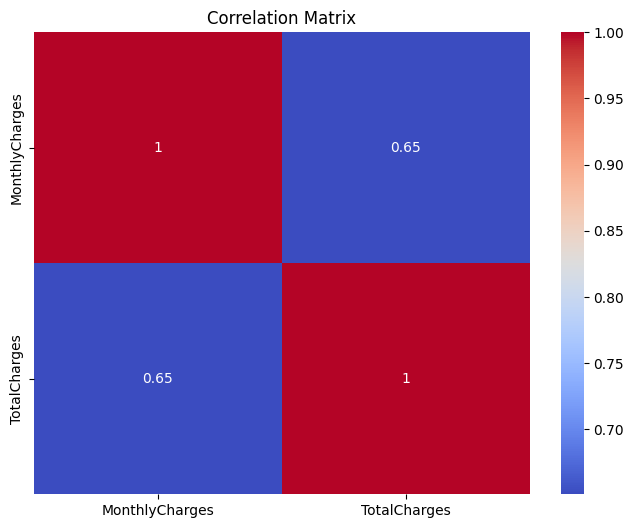

In [27]:
#corelation between numerical features
corr = tele_data[["MonthlyCharges","TotalCharges"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

The resulting heatmap displays a 0.65 at the intersection of MonthlyCharges and TotalCharges.

The 1 value: The diagonal squares are solid dark red with a value of 1 because any variable has a perfect linear correlation with itself (MonthlyCharges vs MonthlyCharges).

The 0.65 Value: This indicates a strong positive correlation between a customer's monthly charges and their total accumulated charges.

## **5. Feature Distribution Analysis**

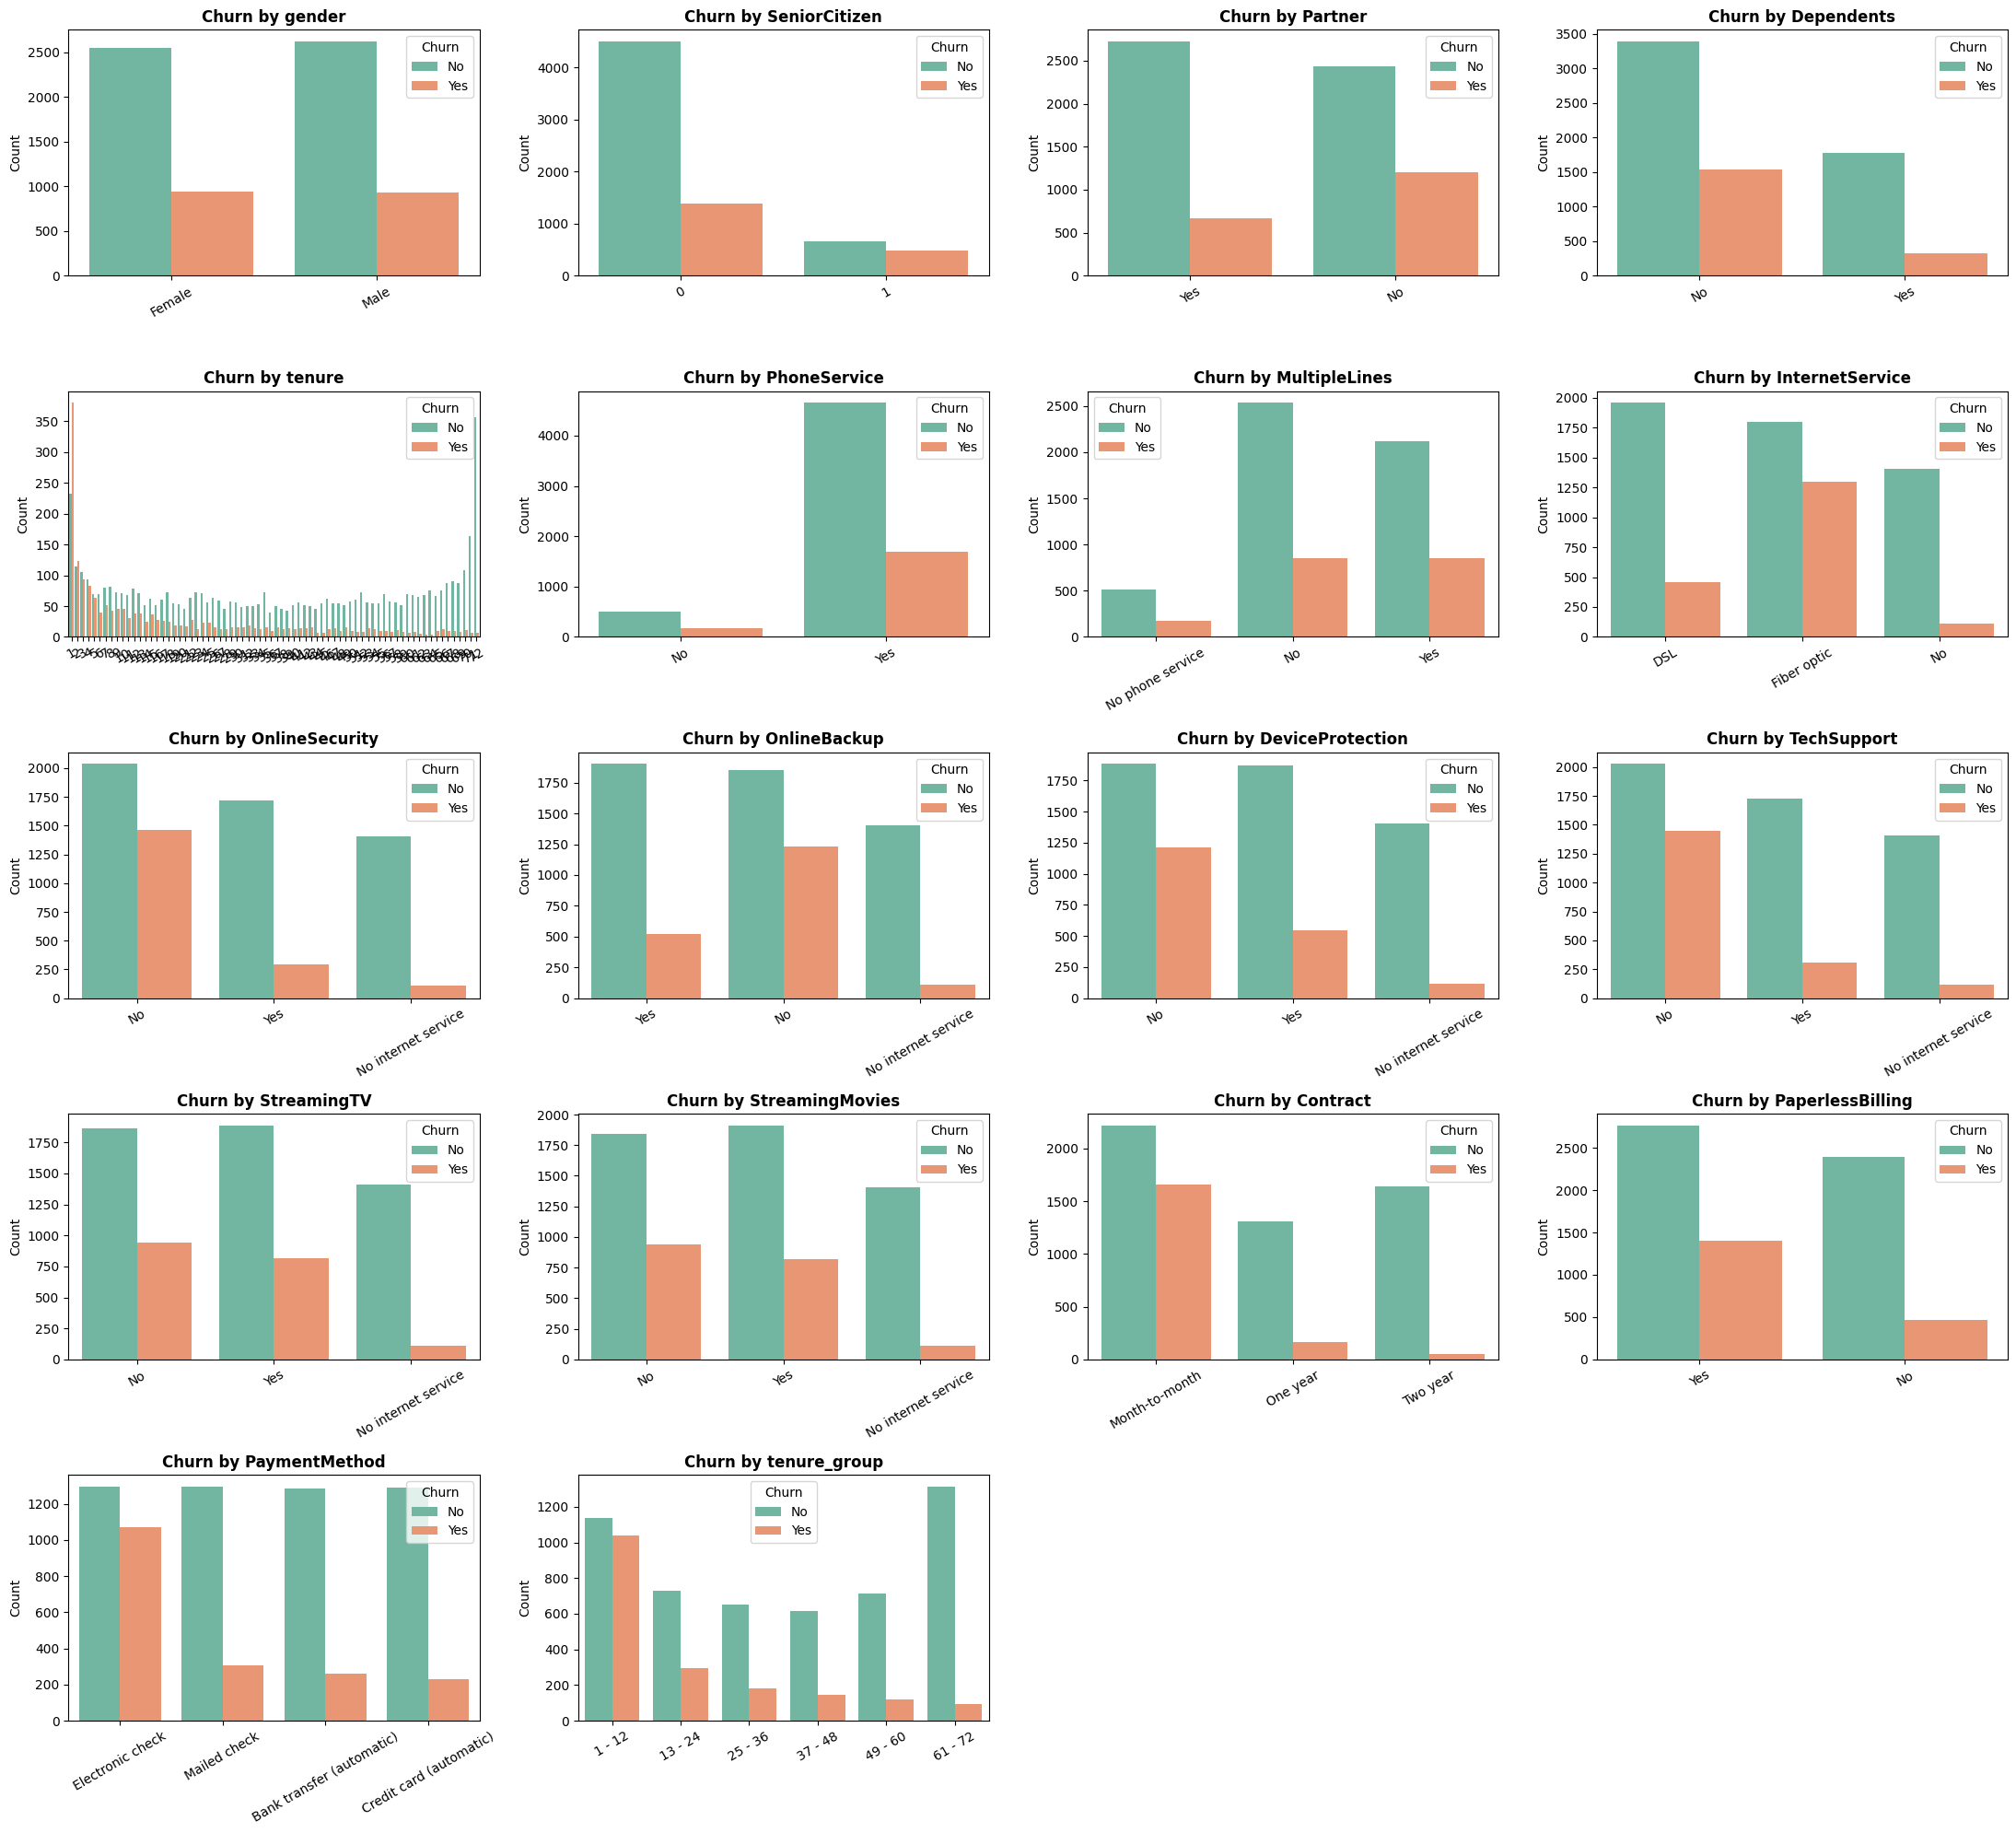

In [28]:
# A code snippet from Google Gemini
# 1. Isolate the categorical features by dropping target and continuous columns
categorical_features = tele_data.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges']).columns

# 2. Setup a grid layout (5 rows, 4 columns fits the 17 categorical features perfectly)
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(22, 20))
axes = axes.flatten()

# 3. Loop through all features using enumerate
for i, predictor in enumerate(categorical_features):
    # Use countplot since these are categorical features
    sns.countplot(data=tele_data, x=predictor, hue='Churn', palette='Set2', ax=axes[i])

    # Setting up clean labels using matplotlib axes
    axes[i].set_title(f'Churn by {predictor}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('') # Removes redundant x-axis column name label
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30) # Rotates categories if text is long

# 4. Clean up: Delete any extra empty subplots at the end of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 5. Fix overlapping text margins
plt.tight_layout()
plt.show()

## **6. Bivariate Analysis**

### 6.1 Churn vs Contract

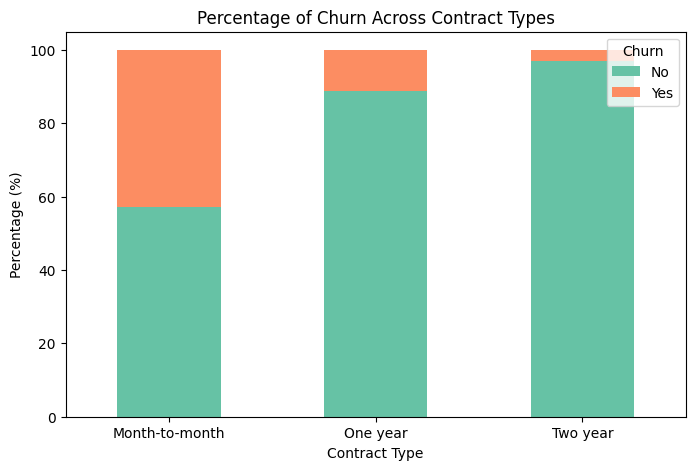

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


In [29]:
# Create a cross-tabulation showing percentages instead of raw counts
contract_churn = pd.crosstab(tele_data['Contract'], tele_data['Churn'], normalize='index') * 100

# Plotting a stacked bar chart
contract_churn.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#66c2a5', '#fc8d62'])
plt.title('Percentage of Churn Across Contract Types')
plt.ylabel('Percentage (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.legend(title='Churn', loc='upper right')
plt.show()

print(contract_churn)

Month-to-month customers churn more

### 6.2 churn vs Online security

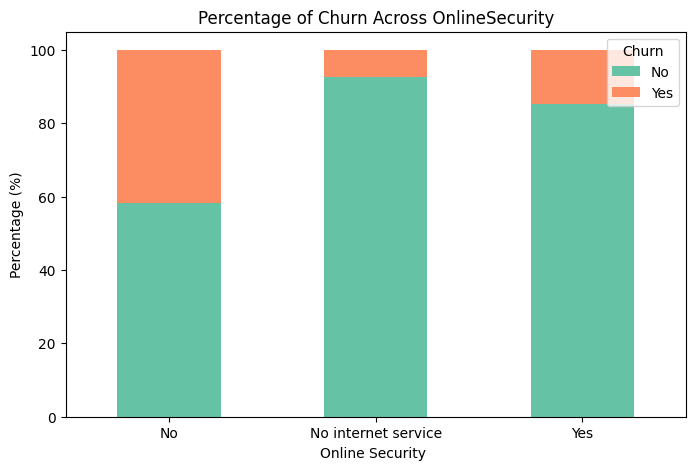

Churn                       No        Yes
OnlineSecurity                           
No                   58.221333  41.778667
No internet service  92.565789   7.434211
Yes                  85.359801  14.640199


In [30]:
# Create a cross-tabulation showing percentages instead of raw counts
online_churn = pd.crosstab(tele_data['OnlineSecurity'], tele_data['Churn'], normalize='index') * 100

# Plotting a stacked bar chart
online_churn.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#66c2a5', '#fc8d62'])
plt.title('Percentage of Churn Across OnlineSecurity')
plt.ylabel('Percentage (%)')
plt.xlabel('Online Security ')
plt.xticks(rotation=0)
plt.legend(title='Churn', loc='upper right')
plt.show()

print(online_churn)

customers with no online security churn more

### 6.3 Churn vs Techsupport

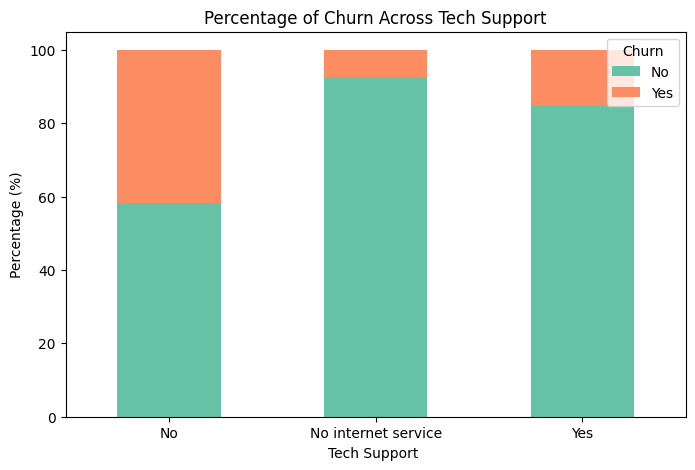

Churn                       No        Yes
TechSupport                              
No                   58.352535  41.647465
No internet service  92.565789   7.434211
Yes                  84.803922  15.196078


In [31]:
# Create a cross-tabulation showing percentages instead of raw counts
tech_churn = pd.crosstab(tele_data['TechSupport'], tele_data['Churn'], normalize='index') * 100

# Plotting a stacked bar chart
tech_churn.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#66c2a5', '#fc8d62'])
plt.title('Percentage of Churn Across Tech Support')
plt.ylabel('Percentage (%)')
plt.xlabel('Tech Support ')
plt.xticks(rotation=0)
plt.legend(title='Churn', loc='upper right')
plt.show()
print(tech_churn)


Costumers with no Tech Support churn more

### 6.4 Churn vs Gender

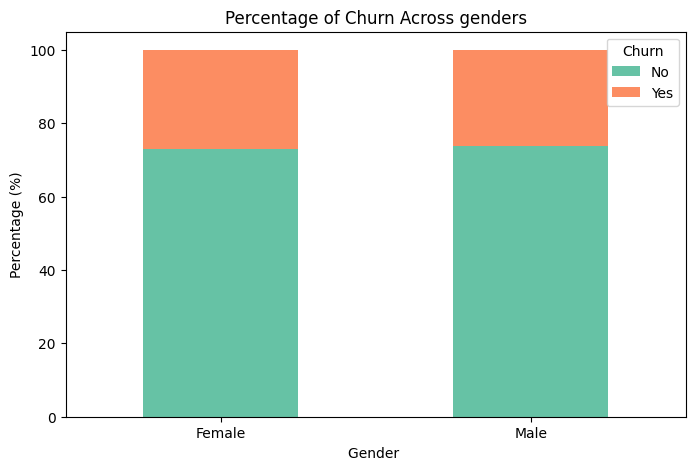

Churn          No        Yes
gender                      
Female  73.040482  26.959518
Male    73.795435  26.204565


In [32]:
# Create a cross-tabulation showing percentages instead of raw counts
gender_churn = pd.crosstab(tele_data['gender'], tele_data['Churn'], normalize='index') * 100

# Plotting a stacked bar chart
gender_churn.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#66c2a5', '#fc8d62'])
plt.title('Percentage of Churn Across genders')
plt.ylabel('Percentage (%)')
plt.xlabel('Gender ')
plt.xticks(rotation=0)
plt.legend(title='Churn', loc='upper right')
plt.show()

print(gender_churn)

Churning of costumer is not affected by gender

### 6.5 Churn vs Tenure groups

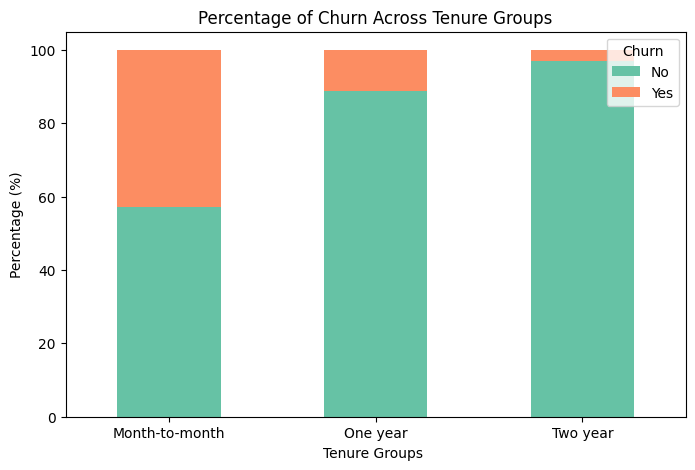

Churn                No        Yes
tenure_group                      
1 - 12        52.321839  47.678161
13 - 24       71.289062  28.710938
25 - 36       78.365385  21.634615
37 - 48       80.971129  19.028871
49 - 60       85.576923  14.423077
61 - 72       93.390192   6.609808


In [33]:
# Create a cross-tabulation showing percentages instead of raw counts
tenure_churn = pd.crosstab(tele_data['tenure_group'], tele_data['Churn'], normalize='index') * 100

# Plotting a stacked bar chart
contract_churn.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#66c2a5', '#fc8d62'])
plt.title('Percentage of Churn Across Tenure Groups')
plt.ylabel('Percentage (%)')
plt.xlabel('Tenure Groups ')
plt.xticks(rotation=0)
plt.legend(title='Churn', loc='upper right')
plt.show()

print(tenure_churn)

Costumer with tenure between 1 t0 12 months churn more

## 7. Buisness insights:

i. Contracts Matter Most: Month-to-month plans are the biggest risk. Nearly    43% of these customers quit, while people who sign 2-year contracts almost
never leave (only about 3% churn).

ii. Financial Visibility & Pricing Pressures: customers are highly price-sensitive. If high monthly charges are combined with a lack of contract lock-in or protective add-ons (like tech support), customers quickly experience bill shock and leave.

ii. Sticky Features Protect Revenue: Customers who do not have Online Security or Tech Support leave at a massive rate (~42%). Adding these features keeps customers around because it makes the service harder to leave.

iv. Gender is Irrelevant: Men and women cancel their subscriptions at the exact same rate (~26%). we can completely ignore gender when trying to predict who will leave.

In [34]:
tele_data.to_csv(
   "/content/Cleaned-Telco-Customer-Churn.csv",
    index=False
)